# Eco-Metric Validation Notebook

This notebook validates the eco-metric used to evaluate generated sustainable smart-home trigger-action rules.

The validation is based on the same set of generated rules evaluated by three independent LLM judges. The goal is to check whether the metric behaves consistently across different judges.

## 1. Evaluation logic

Each judge receives the same original rule and generated rule. The LLM judge does not directly compute the final eco-metric. Instead, it assigns feature-level scores such as occupancy awareness, environmental conditions, duration limits, scheduling, standby reduction, and appliance management.

The final scores are then computed deterministically by the script:

\[
$S_{awareness} = 0.6 \cdot OccupancyScore_{norm} + 0.4 \cdot EnvConditionScore_{norm}$
\]

\[
$S_{energy} = 0.4 \cdot DurationScore_{norm} + 0.4 \cdot StandbyScore_{norm} + 0.1 \cdot ApplianceScore_{norm} + 0.1 \cdot SchedulingScore_{norm}$
\]

\[
$EcoStatic = 0.5 \cdot \Delta_{awareness} + 0.5 \cdot \Delta_{energy}$
\]

The final interpretation is:

| Final label | Meaning |
|---|---|
| `strong_green` | the generated rule has a strong positive green improvement |
| `accept` | the generated rule has a positive but moderate green improvement |
| `reject` | the generated rule is valid, but it does not improve the green score |
| `invalid` | the generated rule breaks the original intent or introduces a comfort/safety risk |

This distinction matters: `reject` means **valid but not green-improving**, while `invalid` means **unsafe or intent-breaking** and should be considered for regeneration.

## 2. Imports and configuration

This section imports the required libraries and defines the paths to the three judge outputs.

If the notebook is moved to another folder, only `DATA_DIR` should need to be changed.

In [3]:
from pathlib import Path
from itertools import combinations
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

try:
    from sklearn.metrics import cohen_kappa_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


# ---------------------------------------------------------------------
# Relative project paths
# ---------------------------------------------------------------------
# This notebook is expected to be executed from the notebooks/ folder.
#
# Therefore:
# - ".." points to the project root
# - "../data/..." points to the project's data folder
#
# No absolute paths are used in this notebook setup.

EXPERIMENT_DIR = (
    Path("..")
    / "data"
    / "synthetic_evaluation"
    / "exp_001"
)

JUDGES_DIR = EXPERIMENT_DIR / "judges"


# ---------------------------------------------------------------------
# Input files: one judgments.jsonl file for each LLM judge
# ---------------------------------------------------------------------
# Each JSONL file contains the judgments produced by one independent LLM judge
# over the same set of generated rules.
#
# Later, these files are merged using:
#     eval_key = rule_id + "::" + generator_model

JUDGE_FILES = {
    "qwen_qwen3_32b": (
        JUDGES_DIR
        / "openrouter_qwen_qwen3_32b"
        / "judgments.jsonl"
    ),
    "openai_gpt_4o_mini": (
        JUDGES_DIR
        / "openrouter_openai_gpt_4o_mini"
        / "judgments.jsonl"
    ),
    "mistral_small_3_2_24b": (
        JUDGES_DIR
        / "openrouter_mistralai_mistral_small_3_2_24b_instruct"
        / "judgments.jsonl"
    ),
}


# ---------------------------------------------------------------------
# Output folder
# ---------------------------------------------------------------------
# All validation outputs generated by this notebook will be saved here.
# This includes merged tables, consensus labels, disagreement cases,
# and summary CSV files useful for the technical report.

OUTPUT_DIR = EXPERIMENT_DIR / "eco_metric_validation_notebook_outputs_en"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Sanity check: verify that all expected files exist
# ---------------------------------------------------------------------
print("Experiment directory:")
print(EXPERIMENT_DIR)
print()

print("Judge files:")
for judge_name, judgment_path in JUDGE_FILES.items():
    print(f"- {judge_name}: {judgment_path} | exists={judgment_path.exists()}")

missing_files = [
    str(judgment_path)
    for judgment_path in JUDGE_FILES.values()
    if not judgment_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Some judgment files were not found:\n"
        + "\n".join(missing_files)
        + "\n\nThis notebook is expected to run from the notebooks/ folder.\n"
        "If you run it from another location, update the relative path in EXPERIMENT_DIR."
    )

print()
print("All judgment files were found successfully.")
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Experiment directory:
..\data\synthetic_evaluation\exp_001

Judge files:
- qwen_qwen3_32b: ..\data\synthetic_evaluation\exp_001\judges\openrouter_qwen_qwen3_32b\judgments.jsonl | exists=True
- openai_gpt_4o_mini: ..\data\synthetic_evaluation\exp_001\judges\openrouter_openai_gpt_4o_mini\judgments.jsonl | exists=True
- mistral_small_3_2_24b: ..\data\synthetic_evaluation\exp_001\judges\openrouter_mistralai_mistral_small_3_2_24b_instruct\judgments.jsonl | exists=True

All judgment files were found successfully.
Outputs will be saved to: ..\data\synthetic_evaluation\exp_001\eco_metric_validation_notebook_outputs_en


## 3. Loading the judgment files

Each `judgments*.jsonl` file contains the evaluation produced by one judge.

The notebook loads all records and creates one merged table with one row per `(rule, judge)` pair.

The key used to align evaluations is:

```text
eval_key = rule_id + "::" + generator_model
```

This makes the comparison robust even if multiple generator models are evaluated in the future.

In [4]:
def load_jsonl(path: Path) -> list[dict]:
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON at line {line_number} in {path}: {exc}") from exc
    return records

rows = []

for judge_name, path in JUDGE_FILES.items():
    records = load_jsonl(path)
    for r in records:
        rows.append({
            "eval_key": f"{r['rule_id']}::{r['generator_model']}",
            "rule_id": r["rule_id"],
            "generator_model": r["generator_model"],
            "target_category": r.get("target_category"),
            "difficulty": r.get("difficulty"),
            "judge": judge_name,
            "judge_model": r.get("judge_model"),
            "label": r.get("label"),
            "eco_label": r.get("eco_label"),
            "generation_status": r.get("generation_status"),
            "needs_regeneration": r.get("needs_regeneration"),
            "invalid_reason": r.get("invalid_reason"),
            "IntentPreserved": r.get("IntentPreserved"),
            "ComfortSafetyPenalty": r.get("ComfortSafetyPenalty"),
            "S_awareness_orig": r.get("S_awareness_orig"),
            "S_awareness_gen": r.get("S_awareness_gen"),
            "S_energy_orig": r.get("S_energy_orig"),
            "S_energy_gen": r.get("S_energy_gen"),
            "Delta_awareness": r.get("Delta_awareness"),
            "Delta_energy": r.get("Delta_energy"),
            "EcoStatic": r.get("EcoStatic"),
            "original_rule": r.get("original_rule"),
            "generated_rule": r.get("generated_rule"),
            "label_reason": r.get("label_reason"),
        })

df = pd.DataFrame(rows)

judge_models = (
    df[["judge", "judge_model"]]
    .drop_duplicates()
    .sort_values("judge")
    .reset_index(drop=True)
)

display(judge_models)
print(f"Total loaded judgments: {len(df)}")
print(f"Unique evaluated examples: {df['eval_key'].nunique()}")

,judge,judge_model
0,mistral_small_3_2_24b,mistralai/mistral-small-3.2-24b-instruct
1,openai_gpt_4o_mini,openai/gpt-4o-mini
2,qwen_qwen3_32b,qwen/qwen3-32b


Total loaded judgments: 1080
Unique evaluated examples: 360


## 4. Coverage check

Before measuring agreement, we need to verify that all three judges evaluated the same set of examples.

If some examples are missing for one judge, agreement would be computed only on the common subset.

In [5]:
coverage = (
    df.groupby("eval_key")
    .agg(
        n_judges=("judge", "nunique"),
        rule_id=("rule_id", "first"),
        generator_model=("generator_model", "first"),
        target_category=("target_category", "first"),
        difficulty=("difficulty", "first"),
    )
    .reset_index()
)

complete_keys = coverage.loc[coverage["n_judges"] == len(JUDGE_FILES), "eval_key"]
df_complete = df[df["eval_key"].isin(complete_keys)].copy()

coverage_summary = pd.DataFrame({
    "metric": ["Unique examples", "Complete examples", "Total judgments used"],
    "value": [df["eval_key"].nunique(), len(complete_keys), len(df_complete)],
})

display(coverage_summary)

if len(complete_keys) == df["eval_key"].nunique():
    display(Markdown("✅ All examples were evaluated by all three judges."))
else:
    display(Markdown("⚠️ Some examples are missing for at least one judge. Agreement will use only complete examples."))

,metric,value
0,Unique examples,360
1,Complete examples,360
2,Total judgments used,1080


✅ All examples were evaluated by all three judges.

## 5. Label distribution by judge

This section checks how each judge distributes the final labels.

This is useful because two judges may have good agreement overall, but one judge may still be more conservative or more generous than the others.

label,strong_green,accept,reject,invalid
judge,,,,
mistral_small_3_2_24b,252,70,30,8
openai_gpt_4o_mini,289,51,18,2
qwen_qwen3_32b,216,108,34,2


label,strong_green,accept,reject,invalid
judge,,,,
mistral_small_3_2_24b,70.00,19.44,8.33,2.22
openai_gpt_4o_mini,80.28,14.17,5.00,0.56
qwen_qwen3_32b,60.00,30.00,9.44,0.56


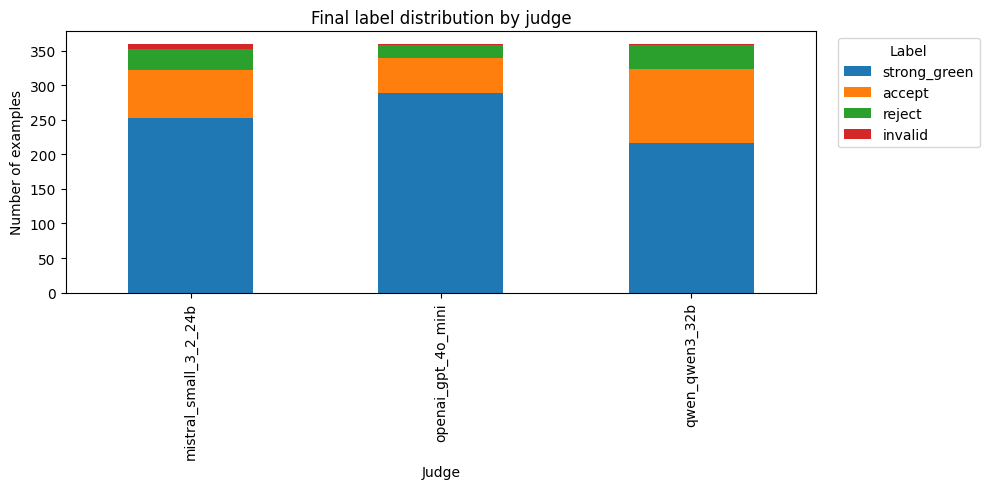

In [6]:
label_order = ["strong_green", "accept", "reject", "invalid"]

label_counts = (
    df_complete.groupby(["judge", "label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

label_percentages = label_counts.div(label_counts.sum(axis=1), axis=0) * 100

display(label_counts)
display(label_percentages.round(2))

ax = label_counts.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Final label distribution by judge")
ax.set_xlabel("Judge")
ax.set_ylabel("Number of examples")
ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation

This plot helps identify judge bias.

For example, if one judge assigns many more `strong_green` labels than the others, that judge is probably more generous. If one judge assigns more `reject` or `invalid` labels, it is probably more conservative.

This does not automatically make a judge wrong. It simply means that majority voting is safer than relying on a single model.

## 6. Reject vs invalid

The difference between `reject` and `invalid` is important for the project.

A `reject` is a valid generation that does not improve the eco-metric. It usually corresponds to:

```text
EcoStatic <= 0
```

An `invalid` generation is more serious. It means that the generated rule either:

```text
IntentPreserved = 0
```

or:

```text
ComfortSafetyPenalty = 1
```

Therefore, `invalid` cases should be considered for regeneration, while `reject` cases can be interpreted as non-improving but not necessarily unsafe or functionally wrong.

generation_status,invalid,valid
judge,,
mistral_small_3_2_24b,8,352
openai_gpt_4o_mini,2,358
qwen_qwen3_32b,2,358


,judge,invalid_reason,count
0,mistral_small_3_2_24b,ComfortSafetyPenalty=1,8
1,openai_gpt_4o_mini,ComfortSafetyPenalty=1,2
2,qwen_qwen3_32b,ComfortSafetyPenalty=1,1
3,qwen_qwen3_32b,IntentPreserved=0,1


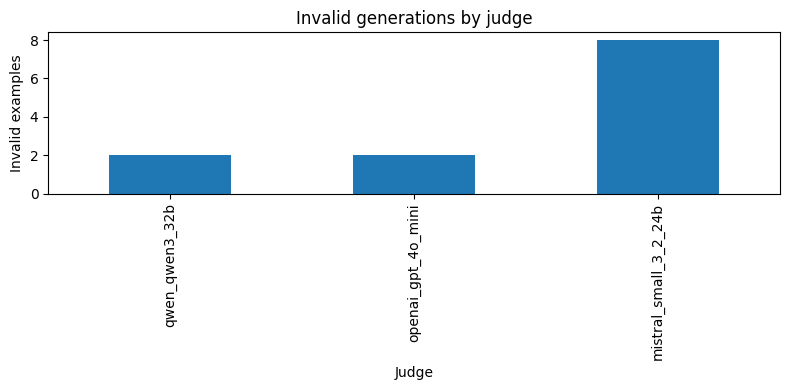

In [7]:
status_counts = (
    df_complete.groupby(["judge", "generation_status"])
    .size()
    .unstack(fill_value=0)
)

display(status_counts)

invalid_cases = df_complete[df_complete["generation_status"] == "invalid"].copy()
invalid_summary = (
    invalid_cases.groupby(["judge", "invalid_reason"])
    .size()
    .reset_index(name="count")
    .sort_values(["judge", "count"], ascending=[True, False])
)

display(invalid_summary)

invalid_by_judge = invalid_cases.groupby("judge").size().reindex(JUDGE_FILES.keys(), fill_value=0)

ax = invalid_by_judge.plot(kind="bar", figsize=(8, 4))
ax.set_title("Invalid generations by judge")
ax.set_xlabel("Judge")
ax.set_ylabel("Invalid examples")
plt.tight_layout()
plt.show()

## 7. Pairwise inter-judge agreement

Agreement is computed pairwise between judges.

For categorical outputs, this notebook reports:

- **Percent agreement**: the percentage of examples where two judges give the same value.
- **Cohen's kappa**: agreement corrected for chance. This is useful because high raw agreement may occur when one class dominates.

The most important fields are:

| Field | Why it matters |
|---|---|
| `label` | final evaluation used by the pipeline |
| `eco_label` | raw eco-metric label before invalid cases are separated |
| `generation_status` | valid vs invalid generation |
| `IntentPreserved` | whether the functional intent is preserved |
| `ComfortSafetyPenalty` | whether comfort/safety risk is introduced |

In [24]:
def pairwise_agreement(data: pd.DataFrame, column: str) -> pd.DataFrame:
    pivot = data.pivot(index="eval_key", columns="judge", values=column)
    results = []

    for j1, j2 in combinations(pivot.columns, 2):
        tmp = pivot[[j1, j2]].dropna()
        percent_agreement = (tmp[j1] == tmp[j2]).mean()

        if SKLEARN_AVAILABLE:
            kappa = cohen_kappa_score(tmp[j1], tmp[j2])
        else:
            kappa = np.nan

        results.append({
            "metric": column,
            "judge_1": j1,
            "judge_2": j2,
            "percent_agreement": percent_agreement,
            "cohen_kappa": kappa,
            "n": len(tmp),
        })

    return pd.DataFrame(results)

categorical_metrics = [
    "label",
    "eco_label",
    "generation_status",
    "IntentPreserved",
    "ComfortSafetyPenalty",
]

agreement = pd.concat(
    [pairwise_agreement(df_complete, metric) for metric in categorical_metrics],
    ignore_index=True,
)

agreement_display = agreement.copy()
agreement_display["percent_agreement"] = (agreement_display["percent_agreement"] * 100).round(2)
agreement_display["cohen_kappa"] = agreement_display["cohen_kappa"].round(3)

display(agreement_display)

agreement.to_csv(OUTPUT_DIR / "eco_metric_inter_judge_agreement.csv", index=False)

c:\Users\rosac\Documents\Github\smart-home-green-rag\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\rosac\Documents\Github\smart-home-green-rag\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)


,metric,judge_1,judge_2,percent_agreement,cohen_kappa,n
0,label,mistral_small_3_2_24b,openai_gpt_4o_mini,78.33,0.467,360
1,label,mistral_small_3_2_24b,qwen_qwen3_32b,78.06,0.573,360
2,label,openai_gpt_4o_mini,qwen_qwen3_32b,72.22,0.410,360
3,eco_label,mistral_small_3_2_24b,openai_gpt_4o_mini,78.33,0.465,360
4,eco_label,mistral_small_3_2_24b,qwen_qwen3_32b,78.06,0.571,360
5,eco_label,openai_gpt_4o_mini,qwen_qwen3_32b,72.22,0.409,360
6,generation_status,mistral_small_3_2_24b,openai_gpt_4o_mini,97.22,-0.009,360
7,generation_status,mistral_small_3_2_24b,qwen_qwen3_32b,97.22,-0.009,360
8,generation_status,openai_gpt_4o_mini,qwen_qwen3_32b,98.89,-0.006,360
9,IntentPreserved,mistral_small_3_2_24b,openai_gpt_4o_mini,100.00,NaN,360


### Agreement visualization

The following chart compares the average pairwise agreement for each categorical metric.

High agreement on `label` means the final eco-metric decision is stable. Lower agreement on `ComfortSafetyPenalty` or `IntentPreserved` would suggest that safety and intent checks are more subjective and should be manually inspected.

,metric,mean_percent_agreement,mean_kappa,mean_percent_agreement_pct
0,ComfortSafetyPenalty,0.978,-0.008,97.778
1,IntentPreserved,0.998,0.000,99.815
2,eco_label,0.762,0.482,76.204
3,generation_status,0.978,-0.008,97.778
4,label,0.762,0.483,76.204


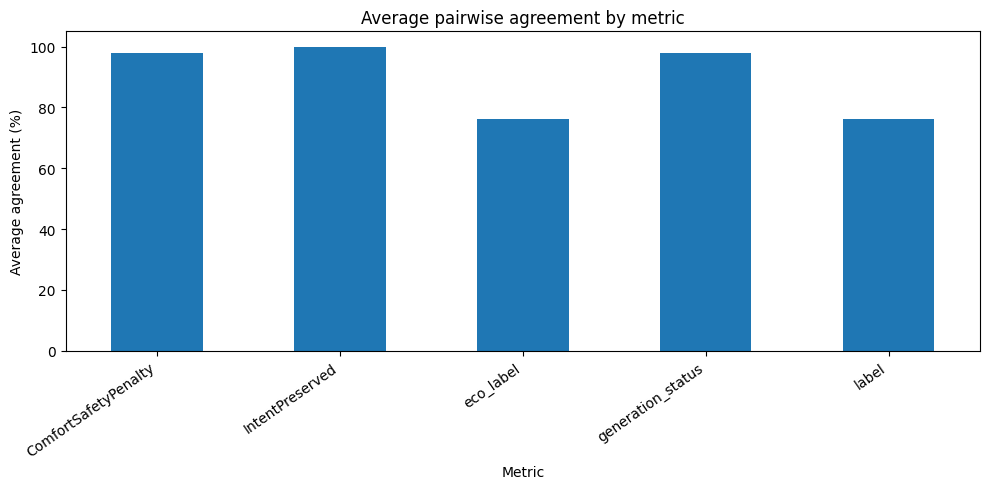

In [25]:
avg_agreement = (
    agreement.groupby("metric")
    .agg(
        mean_percent_agreement=("percent_agreement", "mean"),
        mean_kappa=("cohen_kappa", "mean"),
    )
    .reset_index()
)

avg_agreement["mean_percent_agreement_pct"] = avg_agreement["mean_percent_agreement"] * 100

display(avg_agreement.round(3))

ax = avg_agreement.plot(
    x="metric",
    y="mean_percent_agreement_pct",
    kind="bar",
    figsize=(10, 5),
    legend=False,
)
ax.set_title("Average pairwise agreement by metric")
ax.set_xlabel("Metric")
ax.set_ylabel("Average agreement (%)")
ax.set_ylim(0, 105)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 8. Majority vote consensus

The final label can be made more robust by using majority voting across the three judges.

The consensus rule used here is:

```text
If at least 2 judges agree, use the majority label.
If all 3 judges disagree, mark the example as ambiguous.
```

For numeric scores, the notebook uses the median across judges, because it is less sensitive to one judge being unusually high or low.

In [26]:
def majority_vote(values):
    counts = pd.Series(values).value_counts(dropna=False)
    if counts.empty:
        return np.nan
    if len(counts) > 1 and counts.iloc[0] == counts.iloc[1]:
        return "ambiguous"
    return counts.index[0]

def agreement_level(values):
    counts = pd.Series(values).value_counts(dropna=False)
    if counts.empty:
        return "missing"
    if counts.iloc[0] == 3:
        return "full_agreement"
    if counts.iloc[0] == 2:
        return "majority_agreement"
    return "no_majority"

consensus = (
    df_complete.groupby("eval_key")
    .agg(
        rule_id=("rule_id", "first"),
        generator_model=("generator_model", "first"),
        target_category=("target_category", "first"),
        difficulty=("difficulty", "first"),
        original_rule=("original_rule", "first"),
        generated_rule=("generated_rule", "first"),
        consensus_label=("label", majority_vote),
        label_agreement_level=("label", agreement_level),
        consensus_eco_label=("eco_label", majority_vote),
        consensus_generation_status=("generation_status", majority_vote),
        generation_status_agreement_level=("generation_status", agreement_level),
        consensus_EcoStatic=("EcoStatic", "median"),
        EcoStatic_mean=("EcoStatic", "mean"),
        EcoStatic_std=("EcoStatic", "std"),
        EcoStatic_min=("EcoStatic", "min"),
        EcoStatic_max=("EcoStatic", "max"),
        consensus_Delta_energy=("Delta_energy", "median"),
        Delta_energy_std=("Delta_energy", "std"),
        consensus_Delta_awareness=("Delta_awareness", "median"),
        Delta_awareness_std=("Delta_awareness", "std"),
        n_invalid_votes=("generation_status", lambda x: int((x == "invalid").sum())),
        n_reject_votes=("label", lambda x: int((x == "reject").sum())),
    )
    .reset_index()
)

consensus["EcoStatic_range"] = consensus["EcoStatic_max"] - consensus["EcoStatic_min"]
consensus["final_invalid_majority"] = consensus["n_invalid_votes"] >= 2

consensus_counts = consensus["consensus_label"].value_counts().reindex(
    ["strong_green", "accept", "reject", "invalid", "ambiguous"],
    fill_value=0,
)

agreement_level_counts = consensus["label_agreement_level"].value_counts()

display(consensus_counts.to_frame("count"))
display(agreement_level_counts.to_frame("count"))

consensus.to_csv(OUTPUT_DIR / "eco_metric_consensus_validation.csv", index=False)
df_complete.to_csv(OUTPUT_DIR / "all_judgments_merged.csv", index=False)

,count
consensus_label,
strong_green,253
accept,72
reject,28
invalid,0
ambiguous,7


,count
label_agreement_level,
full_agreement,235
majority_agreement,118
no_majority,7


### Consensus label distribution

This chart shows the final distribution after majority voting.

This is the most useful distribution to report, because it combines the three judge decisions into a single robust label per generated rule.

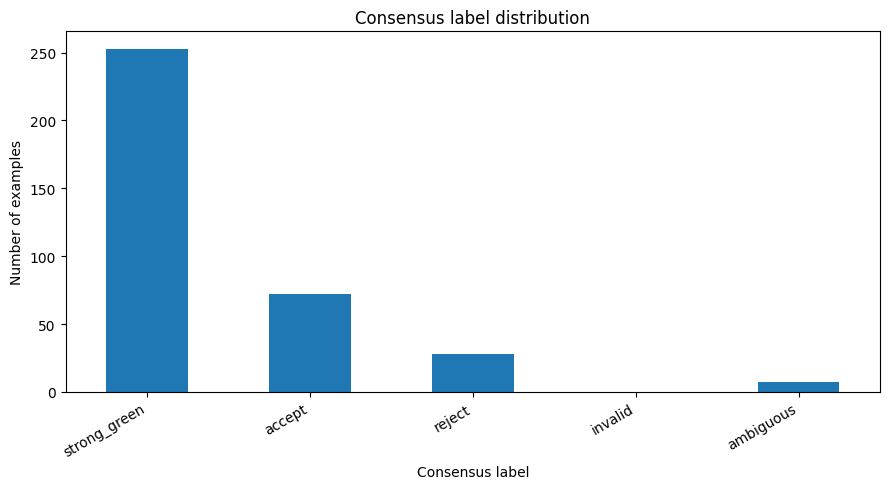

In [27]:
ax = consensus_counts.plot(kind="bar", figsize=(9, 5))
ax.set_title("Consensus label distribution")
ax.set_xlabel("Consensus label")
ax.set_ylabel("Number of examples")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Agreement level distribution

This chart shows how often the judges fully agree, how often there is a 2-out-of-3 majority, and how often there is no majority.

A high number of majority-agreement cases means that majority vote is reliable. A high number of no-majority cases would indicate that the metric or prompt needs refinement.

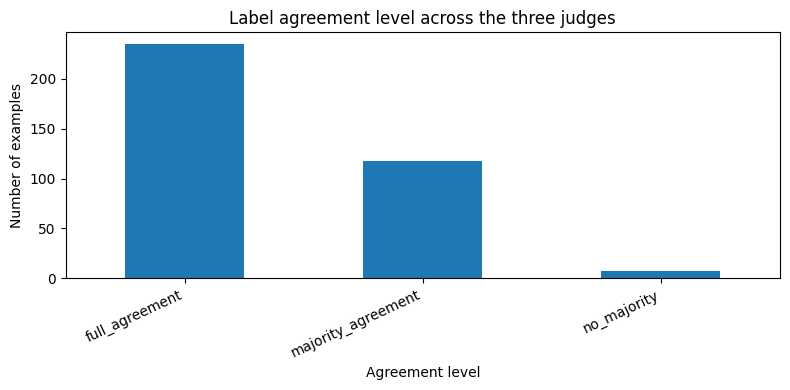

In [28]:
level_order = ["full_agreement", "majority_agreement", "no_majority"]
level_counts = consensus["label_agreement_level"].value_counts().reindex(level_order, fill_value=0)

ax = level_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Label agreement level across the three judges")
ax.set_xlabel("Agreement level")
ax.set_ylabel("Number of examples")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 9. Numerical score stability

Categorical labels are useful, but the eco-metric also produces numeric scores.

This section checks whether judges are numerically consistent on:

- `EcoStatic`
- `Delta_energy`
- `Delta_awareness`

The notebook uses Spearman correlation because we mainly care whether judges rank examples similarly, not whether they produce exactly the same numeric values.

### Spearman correlation for `EcoStatic`

judge,mistral_small_3_2_24b,openai_gpt_4o_mini,qwen_qwen3_32b
judge,,,
mistral_small_3_2_24b,1.000,0.773,0.828
openai_gpt_4o_mini,0.773,1.000,0.754
qwen_qwen3_32b,0.828,0.754,1.000


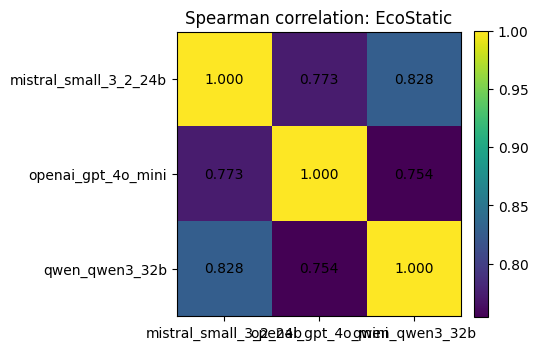

### Spearman correlation for `Delta_energy`

judge,mistral_small_3_2_24b,openai_gpt_4o_mini,qwen_qwen3_32b
judge,,,
mistral_small_3_2_24b,1.000,0.845,0.824
openai_gpt_4o_mini,0.845,1.000,0.843
qwen_qwen3_32b,0.824,0.843,1.000


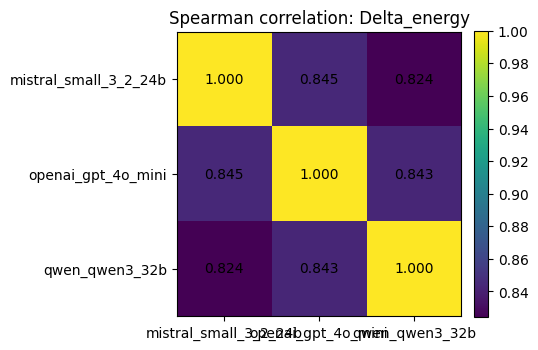

### Spearman correlation for `Delta_awareness`

judge,mistral_small_3_2_24b,openai_gpt_4o_mini,qwen_qwen3_32b
judge,,,
mistral_small_3_2_24b,1.000,0.702,0.754
openai_gpt_4o_mini,0.702,1.000,0.625
qwen_qwen3_32b,0.754,0.625,1.000


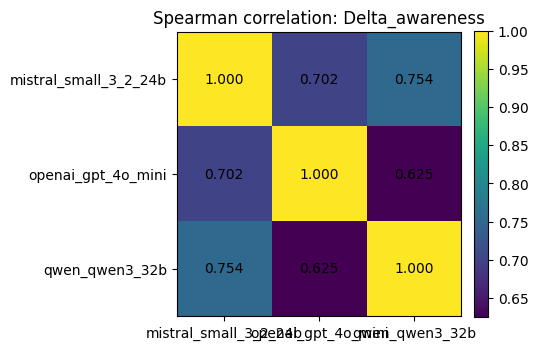

In [29]:
def score_pivot(score_name: str) -> pd.DataFrame:
    return df_complete.pivot(index="eval_key", columns="judge", values=score_name)

def plot_corr_heatmap(corr: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr.values)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

numeric_metrics = ["EcoStatic", "Delta_energy", "Delta_awareness"]
correlation_tables = {}

for metric in numeric_metrics:
    pivot = score_pivot(metric)
    corr = pivot.corr(method="spearman")
    correlation_tables[metric] = corr
    display(Markdown(f"### Spearman correlation for `{metric}`"))
    display(corr.round(3))
    plot_corr_heatmap(corr, f"Spearman correlation: {metric}")

### EcoStatic distribution by judge

The boxplot below compares the distribution of `EcoStatic` values assigned by the three judges.

If one judge is systematically higher, that judge is more generous. If the distributions are similar, the numeric part of the metric is stable.

C:\Users\rosac\AppData\Local\Temp\ipykernel_40668\3919358365.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([eco_pivot[col].dropna() for col in eco_pivot.columns], labels=eco_pivot.columns)


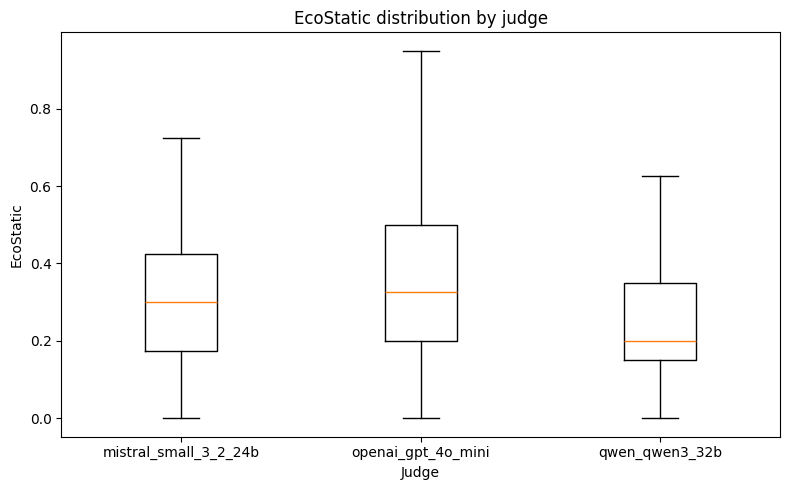

In [30]:
eco_pivot = score_pivot("EcoStatic")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([eco_pivot[col].dropna() for col in eco_pivot.columns], labels=eco_pivot.columns)
ax.set_title("EcoStatic distribution by judge")
ax.set_xlabel("Judge")
ax.set_ylabel("EcoStatic")
plt.tight_layout()
plt.show()

### EcoStatic disagreement

For each example, the notebook computes the range between the maximum and minimum `EcoStatic` assigned by the judges.

A large range means that judges interpreted the rule pair differently. These cases are useful for manual inspection.

,rule_id,target_category,difficulty,consensus_label,label_agreement_level,consensus_EcoStatic,EcoStatic_range,original_rule,generated_rule
70,SYN_COMSEC_MEDIUM_001,comfort_security,medium,strong_green,full_agreement,0.425,0.425,IF Motion is detected outside at night THEN Tu...,IF outdoor motion sensor detects motion AND cu...
195,SYN_LIGHT_MEDIUM_006,lighting_efficiency,medium,strong_green,full_agreement,0.400,0.425,IF The bathroom door opens at night THEN Turn ...,IF bathroom door opens AND time is between 10:...
17,SYN_APP_ALREADY_GOOD_008,appliance_energy_management,already_good,ambiguous,no_majority,0.025,0.425,IF Indoor humidity is above 65% AND the room i...,IF Indoor humidity >65% AND room occupied THEN...
279,SYN_SCHED_MEDIUM_010,scheduling_optimization,medium,strong_green,majority_agreement,0.200,0.400,IF The house is occupied tomorrow morning THEN...,IF house occupancy detected tomorrow morning A...
36,SYN_APP_MEDIUM_007,appliance_energy_management,medium,strong_green,full_agreement,0.400,0.400,IF The water heater temperature is low in the ...,IF water heater temperature < 50°C AND time be...
40,SYN_COMSEC_ADVERSARIAL_001,comfort_security,adversarial,strong_green,full_agreement,0.725,0.400,IF Smoke is detected THEN Sound the alarm and ...,IF Smoke level exceeds threshold AND occupancy...
147,SYN_HVAC_EASY_008,hvac_optimization,easy,strong_green,majority_agreement,0.350,0.375,IF The garage is cold THEN Turn on the garage ...,IF garage temperature < 68°F AND (garage occup...
58,SYN_COMSEC_ALREADY_GOOD_009,comfort_security,already_good,accept,majority_agreement,0.175,0.375,IF The bedroom temperature drops below safe co...,IF bedroom temperature < safe comfort range AN...
144,SYN_HVAC_EASY_005,hvac_optimization,easy,strong_green,full_agreement,0.500,0.375,IF The bedroom feels warm THEN Turn on the fan.,IF bedroom temperature > 24°C AND occupant pre...
151,SYN_HVAC_MEDIUM_002,hvac_optimization,medium,strong_green,majority_agreement,0.325,0.375,IF The bedroom temperature is below 18 degrees...,IF bedroom temperature < 18°C AND time between...


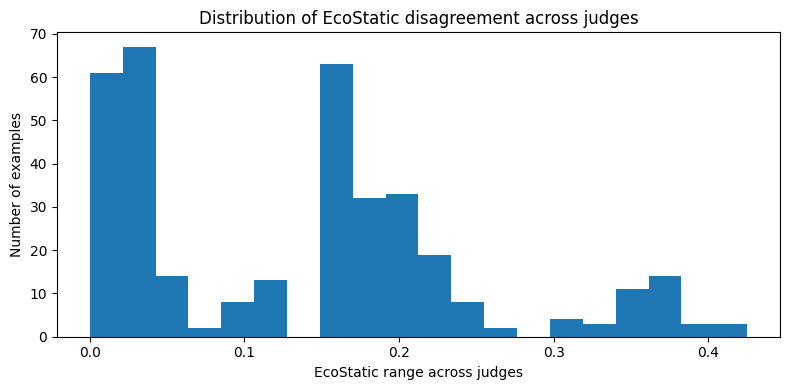

In [31]:
high_range_cases = (
    consensus.sort_values("EcoStatic_range", ascending=False)
    [[
        "rule_id",
        "target_category",
        "difficulty",
        "consensus_label",
        "label_agreement_level",
        "consensus_EcoStatic",
        "EcoStatic_range",
        "original_rule",
        "generated_rule",
    ]]
    .head(20)
)

display(high_range_cases)
high_range_cases.to_csv(OUTPUT_DIR / "high_ecostatic_range_cases.csv", index=False)

ax = consensus["EcoStatic_range"].plot(kind="hist", bins=20, figsize=(8, 4))
ax.set_title("Distribution of EcoStatic disagreement across judges")
ax.set_xlabel("EcoStatic range across judges")
ax.set_ylabel("Number of examples")
plt.tight_layout()
plt.show()

## 10. Analysis by category and difficulty

This section checks whether some categories or difficulty levels are more likely to produce weak or unstable generations.

This can help identify where the generator or the eco-metric needs improvement.

,target_category,n_examples,strong_green_rate,accept_rate,reject_rate,ambiguous_rate,mean_EcoStatic,mean_EcoStatic_std
4,lighting_efficiency,40,80.0,15.0,5.0,0.0,0.356,0.079
1,comfort_security,40,82.5,12.5,2.5,2.5,0.350,0.103
6,scheduling_optimization,40,70.0,20.0,5.0,5.0,0.298,0.079
5,occupancy_based_control,40,72.5,15.0,12.5,0.0,0.292,0.038
7,standby_reduction,40,65.0,22.5,12.5,0.0,0.290,0.053
3,hvac_optimization,40,72.5,20.0,7.5,0.0,0.286,0.083
0,appliance_energy_management,40,67.5,27.5,2.5,2.5,0.266,0.065
2,environmental_awareness,40,52.5,30.0,15.0,2.5,0.231,0.074
8,water_saving,40,70.0,17.5,7.5,5.0,0.224,0.078


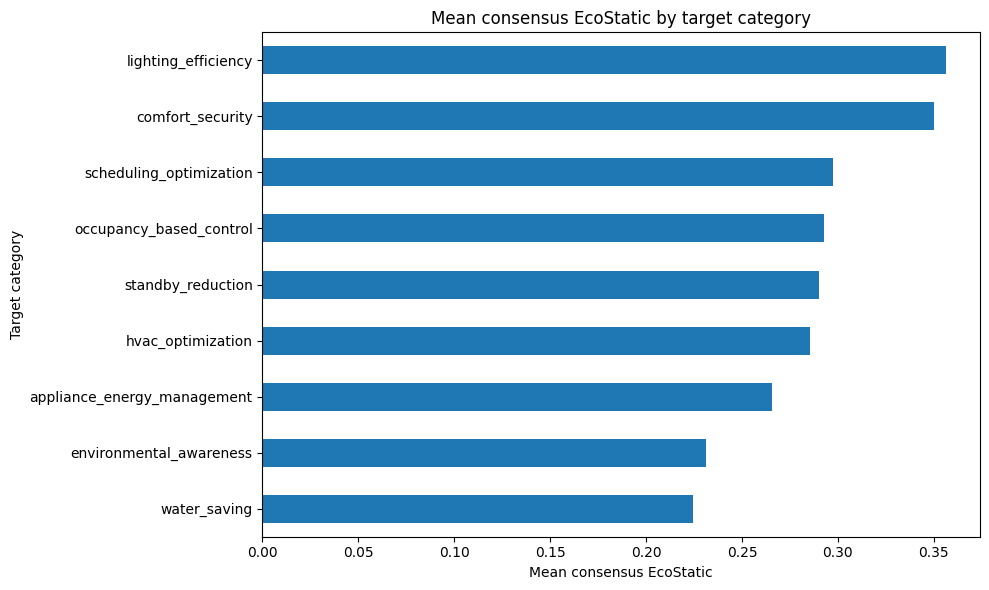

In [32]:
category_summary = (
    consensus.groupby("target_category")
    .agg(
        n_examples=("eval_key", "count"),
        strong_green_rate=("consensus_label", lambda x: (x == "strong_green").mean()),
        accept_rate=("consensus_label", lambda x: (x == "accept").mean()),
        reject_rate=("consensus_label", lambda x: (x == "reject").mean()),
        ambiguous_rate=("consensus_label", lambda x: (x == "ambiguous").mean()),
        mean_EcoStatic=("consensus_EcoStatic", "mean"),
        mean_EcoStatic_std=("EcoStatic_std", "mean"),
    )
    .reset_index()
    .sort_values("mean_EcoStatic", ascending=False)
)

for col in ["strong_green_rate", "accept_rate", "reject_rate", "ambiguous_rate"]:
    category_summary[col] = category_summary[col] * 100

display(category_summary.round(3))
category_summary.to_csv(OUTPUT_DIR / "category_summary.csv", index=False)

ax = category_summary.sort_values("mean_EcoStatic").plot(
    x="target_category",
    y="mean_EcoStatic",
    kind="barh",
    figsize=(10, 6),
    legend=False,
)
ax.set_title("Mean consensus EcoStatic by target category")
ax.set_xlabel("Mean consensus EcoStatic")
ax.set_ylabel("Target category")
plt.tight_layout()
plt.show()

,difficulty,n_examples,strong_green_rate,accept_rate,reject_rate,ambiguous_rate,mean_EcoStatic,mean_EcoStatic_std
0,adversarial,90,75.556,13.333,6.667,4.444,0.309,0.066
1,already_good,90,48.889,28.889,20.000,2.222,0.182,0.062
2,easy,90,81.111,18.889,0.000,0.000,0.366,0.076
3,medium,90,75.556,18.889,4.444,1.111,0.295,0.085


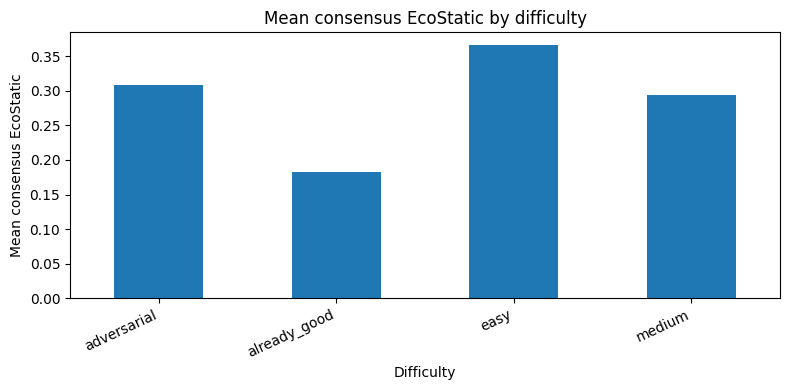

In [33]:
difficulty_summary = (
    consensus.groupby("difficulty")
    .agg(
        n_examples=("eval_key", "count"),
        strong_green_rate=("consensus_label", lambda x: (x == "strong_green").mean()),
        accept_rate=("consensus_label", lambda x: (x == "accept").mean()),
        reject_rate=("consensus_label", lambda x: (x == "reject").mean()),
        ambiguous_rate=("consensus_label", lambda x: (x == "ambiguous").mean()),
        mean_EcoStatic=("consensus_EcoStatic", "mean"),
        mean_EcoStatic_std=("EcoStatic_std", "mean"),
    )
    .reset_index()
)

for col in ["strong_green_rate", "accept_rate", "reject_rate", "ambiguous_rate"]:
    difficulty_summary[col] = difficulty_summary[col] * 100

display(difficulty_summary.round(3))
difficulty_summary.to_csv(OUTPUT_DIR / "difficulty_summary.csv", index=False)

ax = difficulty_summary.plot(
    x="difficulty",
    y="mean_EcoStatic",
    kind="bar",
    figsize=(8, 4),
    legend=False,
)
ax.set_title("Mean consensus EcoStatic by difficulty")
ax.set_xlabel("Difficulty")
ax.set_ylabel("Mean consensus EcoStatic")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 11. Manual audit candidates

The most useful examples for manual inspection are not random examples. They are the examples where the automatic evaluation is uncertain.

This notebook selects three groups:

1. Examples where all three judges gave different labels.
2. Examples marked invalid by exactly one judge.
3. Examples with the largest `EcoStatic` range across judges.

These examples should be manually inspected and discussed in the report.

In [34]:
label_disagreements = consensus[consensus["label_agreement_level"] == "no_majority"].copy()

single_judge_invalid = consensus[
    (consensus["n_invalid_votes"] == 1) &
    (consensus["final_invalid_majority"] == False)
].copy()

manual_audit = pd.concat([
    label_disagreements.assign(audit_reason="no_majority_label"),
    single_judge_invalid.assign(audit_reason="single_judge_invalid"),
    consensus.sort_values("EcoStatic_range", ascending=False).head(20).assign(audit_reason="high_ecostatic_range"),
], ignore_index=True)

manual_audit = manual_audit.drop_duplicates(subset=["eval_key", "audit_reason"])

cols = [
    "audit_reason",
    "rule_id",
    "target_category",
    "difficulty",
    "consensus_label",
    "label_agreement_level",
    "n_invalid_votes",
    "consensus_EcoStatic",
    "EcoStatic_range",
    "original_rule",
    "generated_rule",
]

manual_audit = manual_audit[cols].sort_values(["audit_reason", "rule_id"])

display(manual_audit)
manual_audit.to_csv(OUTPUT_DIR / "manual_audit_candidates.csv", index=False)

,audit_reason,rule_id,target_category,difficulty,consensus_label,label_agreement_level,n_invalid_votes,consensus_EcoStatic,EcoStatic_range,original_rule,generated_rule
21,high_ecostatic_range,SYN_APP_ALREADY_GOOD_008,appliance_energy_management,already_good,ambiguous,no_majority,0,0.025,0.425,IF Indoor humidity is above 65% AND the room i...,IF Indoor humidity >65% AND room occupied THEN...
23,high_ecostatic_range,SYN_APP_MEDIUM_007,appliance_energy_management,medium,strong_green,full_agreement,0,0.400,0.400,IF The water heater temperature is low in the ...,IF water heater temperature < 50°C AND time be...
24,high_ecostatic_range,SYN_COMSEC_ADVERSARIAL_001,comfort_security,adversarial,strong_green,full_agreement,0,0.725,0.400,IF Smoke is detected THEN Sound the alarm and ...,IF Smoke level exceeds threshold AND occupancy...
26,high_ecostatic_range,SYN_COMSEC_ALREADY_GOOD_009,comfort_security,already_good,accept,majority_agreement,0,0.175,0.375,IF The bedroom temperature drops below safe co...,IF bedroom temperature < safe comfort range AN...
30,high_ecostatic_range,SYN_COMSEC_EASY_003,comfort_security,easy,accept,majority_agreement,0,0.150,0.375,IF The bedroom gets cold THEN Turn on heating.,IF bedroom temperature < 20°C AND bedroom occu...
19,high_ecostatic_range,SYN_COMSEC_MEDIUM_001,comfort_security,medium,strong_green,full_agreement,0,0.425,0.425,IF Motion is detected outside at night THEN Tu...,IF outdoor motion sensor detects motion AND cu...
37,high_ecostatic_range,SYN_ENV_EASY_008,environmental_awareness,easy,accept,majority_agreement,0,0.150,0.375,IF It is cold outside THEN Turn on heating.,IF Outside temperature < 18°C AND Occupancy se...
27,high_ecostatic_range,SYN_HVAC_EASY_005,hvac_optimization,easy,strong_green,full_agreement,0,0.500,0.375,IF The bedroom feels warm THEN Turn on the fan.,IF bedroom temperature > 24°C AND occupant pre...
36,high_ecostatic_range,SYN_HVAC_EASY_006,hvac_optimization,easy,accept,majority_agreement,0,0.150,0.375,IF The living room is cold THEN Increase the t...,IF Living room temperature < 20°C AND Occupanc...
38,high_ecostatic_range,SYN_HVAC_EASY_007,hvac_optimization,easy,strong_green,majority_agreement,0,0.375,0.375,IF The house is hot THEN Turn on all air condi...,IF house temperature > 27°C AND occupants pres...


## 12. Summary for the technical report

The following cell automatically creates a short textual summary that can be adapted for the final report.

In [35]:
n_examples = consensus.shape[0]
full_agree = int((consensus["label_agreement_level"] == "full_agreement").sum())
majority_agree = int((consensus["label_agreement_level"] == "majority_agreement").sum())
no_majority = int((consensus["label_agreement_level"] == "no_majority").sum())
at_least_majority = full_agree + majority_agree

consensus_label_counts = consensus["consensus_label"].value_counts()
strong_green_n = int(consensus_label_counts.get("strong_green", 0))
accept_n = int(consensus_label_counts.get("accept", 0))
reject_n = int(consensus_label_counts.get("reject", 0))
ambiguous_n = int(consensus_label_counts.get("ambiguous", 0))

invalid_any = int((consensus["n_invalid_votes"] >= 1).sum())
invalid_majority = int((consensus["n_invalid_votes"] >= 2).sum())

# Average Spearman correlation excluding diagonal.
def mean_off_diagonal(corr: pd.DataFrame) -> float:
    values = []
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            if i < j:
                values.append(corr.iloc[i, j])
    return float(np.mean(values))

eco_corr_mean = mean_off_diagonal(correlation_tables["EcoStatic"])
energy_corr_mean = mean_off_diagonal(correlation_tables["Delta_energy"])
awareness_corr_mean = mean_off_diagonal(correlation_tables["Delta_awareness"])

summary_text = f"""
The eco-metric was validated on {n_examples} generated rule pairs evaluated by three independent LLM judges. 
All three judges evaluated the same examples, allowing a direct inter-judge comparison. 
The judges fully agreed on the final label for {full_agree}/{n_examples} examples ({full_agree / n_examples:.1%}), while at least two judges agreed for {at_least_majority}/{n_examples} examples ({at_least_majority / n_examples:.1%}). 
Only {no_majority}/{n_examples} examples ({no_majority / n_examples:.1%}) had no majority label and were therefore marked as ambiguous.

The consensus label distribution was: {strong_green_n} strong_green, {accept_n} accept, {reject_n} reject, and {ambiguous_n} ambiguous examples. 
Invalidity detection was more judge-dependent: {invalid_any} examples were marked invalid by at least one judge, but {invalid_majority} examples received an invalid majority. 
Therefore, single-judge invalid cases should be manually inspected rather than automatically discarded.

The numerical component of the eco-metric was also stable. 
The average pairwise Spearman correlation was {eco_corr_mean:.3f} for EcoStatic, {energy_corr_mean:.3f} for Delta_energy, and {awareness_corr_mean:.3f} for Delta_awareness. 
This suggests that the judges tend to rank generated rules similarly, especially for energy-related improvements.
""".strip()

display(Markdown(summary_text.replace("\n", "\n\n")))

with (OUTPUT_DIR / "technical_report_summary.md").open("w", encoding="utf-8") as f:
    f.write(summary_text + "\n")

The eco-metric was validated on 360 generated rule pairs evaluated by three independent LLM judges. 

All three judges evaluated the same examples, allowing a direct inter-judge comparison. 

The judges fully agreed on the final label for 235/360 examples (65.3%), while at least two judges agreed for 353/360 examples (98.1%). 

Only 7/360 examples (1.9%) had no majority label and were therefore marked as ambiguous.



The consensus label distribution was: 253 strong_green, 72 accept, 28 reject, and 7 ambiguous examples. 

Invalidity detection was more judge-dependent: 12 examples were marked invalid by at least one judge, but 0 examples received an invalid majority. 

Therefore, single-judge invalid cases should be manually inspected rather than automatically discarded.



The numerical component of the eco-metric was also stable. 

The average pairwise Spearman correlation was 0.785 for EcoStatic, 0.837 for Delta_energy, and 0.694 for Delta_awareness. 

This suggests that the judges tend to rank generated rules similarly, especially for energy-related improvements.

## 13. Exported files

The notebook exports the following files:

| File | Purpose |
|---|---|
| `all_judgments_merged.csv` | all judge outputs merged into one table |
| `eco_metric_inter_judge_agreement.csv` | pairwise agreement statistics |
| `eco_metric_consensus_validation.csv` | one consensus row per generated rule |
| `category_summary.csv` | performance grouped by target category |
| `difficulty_summary.csv` | performance grouped by difficulty |
| `high_ecostatic_range_cases.csv` | examples with large numeric disagreement |
| `manual_audit_candidates.csv` | examples recommended for manual inspection |
| `technical_report_summary.md` | short English summary for the report |

In [36]:
print(f"Export directory: {OUTPUT_DIR}")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Export directory: ..\data\synthetic_evaluation\exp_001\eco_metric_validation_notebook_outputs_en
- all_judgments_merged.csv
- category_summary.csv
- difficulty_summary.csv
- eco_metric_consensus_validation.csv
- eco_metric_inter_judge_agreement.csv
- high_ecostatic_range_cases.csv
- manual_audit_candidates.csv
- technical_report_summary.md
